# Optimization 1 - The need for calculus in ML

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

## 1 Optimization

### 1.1 Error vs Classifier

![Error vs Classifier](images/error_vs_classifier.png)

1. Each classifier (line/Decision-Boundary) will have an error associated to it.
2. Error associated with the classifier tells us how bad the classifier is.
3. The goal is to have **minimum error** i.e., identify classifier with lowest error.
4. In the above graph, classifier #5 has the lowest error among all the $k$ number of classifiers.

#### What is Optimization?

Finding optimal weights for the best classifier.

### 1.2 Linear Search Method

Brute-force or linear search method of finding best weights between the range `[-10, +10]` with step size of `0.1`:

In [2]:
w_range = np.arange(-10, 10.1, 0.1).round(2)
print(f"{len(w_range)} values for each weight.")

201 values for each weight.


will have 201 values for each weight.

Suppose we need to find best weights for a line (2D Hyper-plane) which has three weight values $\{w_1, w_2\}$ and $w_0$

In [3]:
wc = 3  # Number of weight parameters to train.
wr = 201  # Range of values.
ti_3 = 201**3  # Total number of iterations.

print("Weights count:", wc)
print("Values range:", wr)
print(f"Iterations: {ti_3:,}")

Weights count: 3
Values range: 201
Iterations: 8,120,601


In worst case scenario, finding best values for 3 weights from a range of 201 values takes: 8,120,601 iterations.

In [4]:
t = 10**-6  # Time per iterations.
tr_3 = t * ti_3  # Total time taken for 3 parameters.
tr_4 = t * (201**4)  # Total time taken for 4 parameters.
tr_5 = t * (201**5)  # Total time taken for 5 parameters.
tr_6 = t * (201**6)  # Total time taken for 6 parameters.

print("Training time for 3 parameters:", round(tr_3, 2), "seconds")
print("Training time for 4 parameters:", tr_4 // 60, "minutes")
print("Training time for 5 parameters:", tr_5 // 60 // 60, "hours")
print("Training time for 6 parameters:", tr_6 // 60 // 60 // 24, "days")

Training time for 3 parameters: 8.12 seconds
Training time for 4 parameters: 27.0 minutes
Training time for 5 parameters: 91.0 hours
Training time for 6 parameters: 763.0 days


#### Need for Optimization

- So total time taken to train (identify best weights) a model with 5 parameters using Linear Search method roughly takes 91 hours.
- In real world scenario there will be thousands/millions/billions of parameters to train and Linear Search method cannot be scaled.
- Hence there is a need for some optimization technique to identify best weights.
- Optimization is achieved using **Gradient Descent** algorithm.

#### Why is it important to find optimal weights?

Mapping function for Binary Classification:

$$
\large
\begin{aligned}
\hat{y} = f(x) =&\; w_1 x_1 + w_2 x_2 + \ldots +  w_d x_d + w_0 \\[3pt]
                &\; \text{or}               \\[3pt]
                &\; w^T x + w_0
\end{aligned}
$$

- The mapping function for a Binary Classifier has two vectors $\vec{w}$ and $\vec{x}$ in the dot product.
- The feature vector $\vec{x}$ is the **given dataset and cannot be modified**.
- Hence the only one remaining variable component in the dot product is weight vector $\vec{w}$.
- $w_0$ is also part of optimization.

### 1.3 Gradient Descent

1. Optimally computing the weight vector $\vec{w}$ and $w_0$ value.
2. Much faster than brute force (Linear Search method).
3. Gradient Descent uses controlled searching.
4. Gradient Descent achieves this using the concept of **Maxima** and **Minima**.

#### Maximization

Process of finding **maxima** is called as Maximization.

#### Minimization

Process of finding **minima** is called as Minimization.

> **Note**:
>
> Calculus is used to find minima.

#### In ML Context

To reach the goal of finding minima we need to understand below chain of concepts:

1. What is a Function? and types of Functions.
2. Understand Continuous and Discontinuous functions.
3. How to find derivative of a Continuous function?
4. After obtaining derivative, relationship between derivatives, slope and tangent.
5. How slope helps in Calculus?
6. How slope helps in Minimization?

##### Topics

1. Maxima or Minima.
2. Calculus for multiple variables.
3. Calculus for single variable.
4. Derivatives, Slopes and Tangents
5. Limits, Continuity and Differentiability.

### 1.4 Gain Function

#### Formula

Equation for Optimization of Gain Function for Binary Classification:

$$
\large
\begin{aligned}
w^*, w_0^* &= \arg\max_{w, w_0} \quad g(D, \vec{w}, w_0) \\[5pt]
           &= \arg\max_{w, w_0} \frac{1}{n} \sum_{i=1}^n \frac{w^T x^{(i)} \;+\; w_0}{\Vert{w}\Vert} \cdot y^{(i)}
\end{aligned}
$$

#### Objective

**Maximize Gain function**.

### 1.5 Loss Function

#### Formula

Equation for Optimization of Loss Function for Binary Classification:

$$
\large
\begin{aligned}
w^*, w_0^* &= \arg\min_{w, w_0} \quad l(D, \vec{w}, w_0) \\[5pt]
           &= \arg\min_{w, w_0} \frac{1}{n} \sum_{i=1}^n \frac{w^T x^{(i)} \;+\; w_0}{\Vert{w}\Vert} \cdot y^{(i)}
\end{aligned}
$$

#### Objective

**Minimize Loss function**.

### 1.6 Mathematical Notations

Mathematical notations in ML Context.

#### Dataset

A labeled dataset $D$ is represented as:

$$
\large
\begin{aligned}
D := \biggl\{\bigl(x_i, y_i \bigr)\;;\;x\in\mathbb{R}^d\;;\;y\in\{-1,+1\}\biggr\}_{i=1}^n
\end{aligned}
$$

Where,

- $D$ is Dataset
- $x$ are features
- $y$ are labels
- $n$ is the size of the dataset

#### Mapping Function

$$
\large
\begin{aligned}
\hat{y} = f(x) =&\; w_1 x_1 + w_2 x_2 + \ldots +  w_d x_d + w_0 \\[3pt]
                &\; \text{or}                                   \\[3pt]
               =&\; w^T x + w_0
\end{aligned}
$$

#### Optimization

$$
\large
\begin{aligned}
g(x, y, \vec{w}, w_0) = \arg\max_{w, w_0} \frac{1}{n} \sum_{i=1}^n \frac{w^T x^{(i)} \;+\; w_0}{\Vert{w}\Vert} \cdot y^{(i)}
\end{aligned}
$$

$$
\large
\begin{aligned}
g(D, \vec{w}, w_0) = \arg\max_{w, w_0} \frac{1}{n} \sum_{i=1}^n \frac{w^T x^{(i)} \;+\; w_0}{\Vert{w}\Vert} \cdot y^{(i)}
\end{aligned}
$$

Where $D$ in Gain function $g(D, \vec{w}, w_0)$ will be fixed.

## 2 Functions

### 2.1 Function

#### Definition

A function is a mapping between input and output. 

#### Mathematical Notation

Mathematical notation of a function:

$$
\large
\begin{aligned}
f(x) = y
\end{aligned}
$$

where,

- $x$ is input
- $y$ is output

#### Properties of Function

1. A **valid** function $f(x)$ must always return single value for given input $x$.
2. Set of all possible **inputs** to a function is called as **Domain**.
3. Set of all possible **outputs** from a function is called as **Range**.

### 2.2 Domain and Range

#### Domain

1. Set of all possible values for input $x$.
2. In ML context, Domain can be a $x$ matrix (collection of all feature vector).

#### Range

1. Collection of all possible values for output $y$.
2. In ML context, considering binary classification, $y \in \{+1, -1\}$.

### 2.2 Types of Functions

There are two types of functions:

1. Continuous Function
2. Discontinuous Function

#### Continuous Function

A function is a continuous function if it satisfies below two conditions: 

1. The **left-hand limit** at $x = a$ **must be equal** to the **right-hand limit** at $x = a$
2. Both the limits (LHS and RHS) must be equal to the function value at $x = a$.

$ \text{Left hand limit} = \text{Right hand limit}$

##### Example #1

$f(x) = x^2$

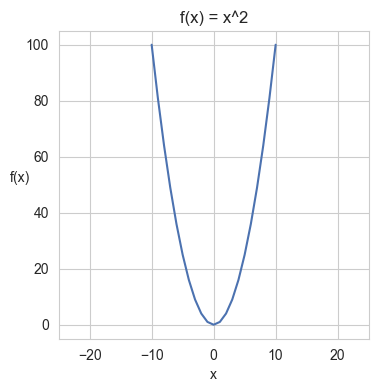

In [5]:
x = np.arange(-10, 11, 1)
y = x**2

plt.figure(figsize=(4, 4))
sns.lineplot(x=x, y=y)
plt.title("f(x) = x^2")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)
plt.xlim(-25, 25)

# plt.savefig("images/function_continuous_example.png")
plt.show()

##### Example #2

$f(x) = \sin x$

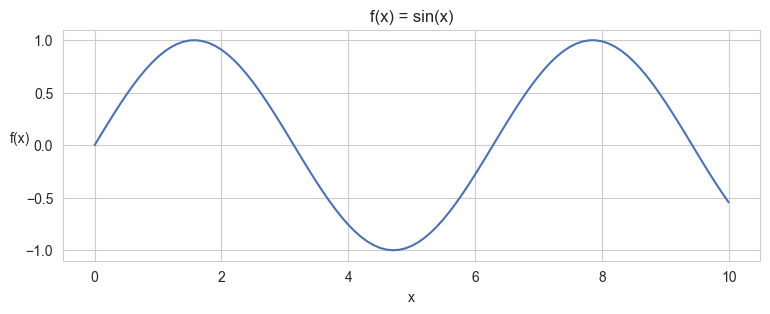

In [6]:
x = np.arange(0, 10.1, 0.1)
y = np.sin(x)

plt.figure(figsize=(9, 3))
sns.lineplot(x=x, y=y)
plt.title("f(x) = sin(x)")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)

plt.show()

##### Example #3

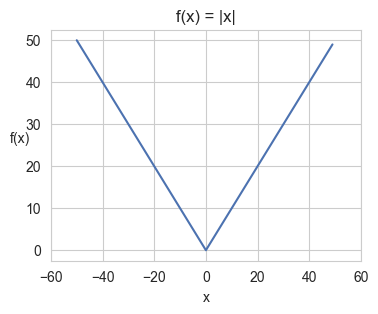

In [7]:
x = np.arange(-50, 50, 1)
y = np.abs(x)

plt.figure(figsize=(4, 3))
sns.lineplot(x=x, y=y)
plt.title("f(x) = |x|")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)
plt.xlim(-60, 60)

plt.show()

> **Note**:  
> While $f(x) = \vert{x}\vert$ is continuous function but it is **not differentiable at** $x = 0$

#### Discontinuous Function

A function is a discontinuous function if the **left-hand limit** at $x = a$ **is not equal** to the **right-hand limit** at $x = a$.

$ \text{Left hand limit} \ne \text{Right hand limit}$

##### Example #1

Step function

$$
\large
\begin{aligned}
f(x) &= 1 & \text{if}\; x > 0 \\
f(x) &= -1 & \text{if}\; x < 0 \\
f(x) &= 0 & \text{if}\; x = 0
\end{aligned}
$$

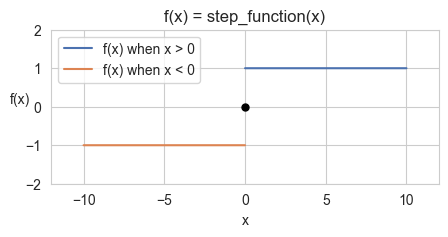

In [8]:
x1 = np.arange(0.001, 10, 0.001)
y1 = np.where(x1 > 0, 1, -1)

x2 = np.arange(-10, -0.001, 0.001)
y2 = np.where(x2 < 0, -1, 1)

plt.figure(figsize=(5, 2))
sns.lineplot(x=x1, y=y1, label="f(x) when x > 0")
sns.lineplot(x=x2, y=y2, label="f(x) when x < 0")
plt.plot(0, 0, marker="o", markersize=5, color="k")
plt.title("f(x) = step_function(x)")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)
plt.xlim(-12, 12)
plt.ylim(-2, 2)

plt.show()

##### Example #2

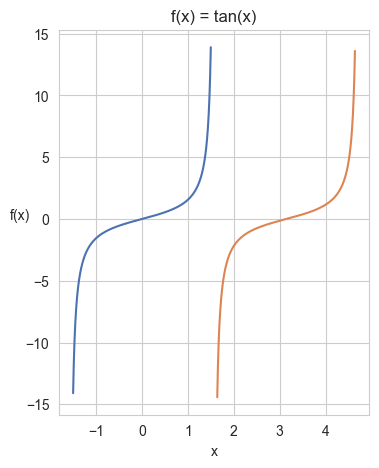

In [9]:
x1 = np.arange(-1.5, 1.5, 0.001)
y1 = np.tan(x1)

x2 = np.arange(1.64, 4.64, 0.001)
y2 = np.tan(x2)

plt.figure(figsize=(4, 5))
sns.lineplot(x=x1, y=y1)
sns.lineplot(x=x2, y=y2)
plt.title("f(x) = tan(x)")
plt.xlabel("x")
plt.ylabel("f(x)", rotation=0)

# plt.savefig("images/function_discontinuous_example.png")
plt.show()

##### Example #3

`ceil()` function in Python.

> **Note**:  
> In layman terms,
> 1. A function that can be drawn **without lifting a pen** is called as Continuous Function.
> 2. A function that cannot be drawn **without lifting a pen** is called as Discontinuous Function.

### 2.3 Derivatives

#### Properties

1. Derivatives are calculated using limits.
2. Limits are applied on the continuous functions.

#### Derivative of a Function

**Q**: What does the derivative of a function represent?  

**Ans**:

The **slope of the tangent** line to the function's graph at a given point.

#### Slope vs Tangent

**Q**: Why is it useful to find the slope of a tangent?

**Ans**:

1. Slope is zero at minima/maxima point.
2. Slope is calculated using Tangent.

#### Derivatives vs Slope

**Q**: How Derivatives use Slope to calculate minima?

**Ans**:

1. Only continuous functions are differentiable.
2. For a differentiable function, points where slope = 0 are critical points. A minimum occurs only if the second derivative is positive at that point.